# dc1d: seeing the deformable convolution work

`dc1d` is a pure-PyTorch 1D deformable convolution. A deformable convolution is an
ordinary convolution in which every kernel tap is free to move: instead of reading the
input at a fixed grid position, each tap reads at a *learned*, real-valued offset from
that position, and the value there is obtained by linear interpolation between the two
neighbouring samples. Because the interpolation is differentiable, the offsets can be
trained by backpropagation along with the weights.

This notebook shows, on tensors small enough to plot, that the layer does what that
sentence says. Six properties, in order:

1. Zero offsets reproduce `nn.Conv1d` exactly.
2. An integer offset of `n` shifts the sampled signal by exactly `n`.
3. A fractional offset linearly interpolates between neighbours.
4. The gradient with respect to the offsets is correct, including the case that used to
   be wrong.
5. Sampling positions stay exact in low precision.
6. The offsets actually learn.

Nothing here needs a GPU, and the whole notebook runs in a few seconds on a laptop.

## Running it

```
uv sync --group demo
uv run --group demo jupyter lab docs/demo.ipynb
```

or non-interactively, which is how the committed outputs were produced:

```
uv run --group demo jupyter nbconvert --to notebook --execute --inplace docs/demo.ipynb
```

Every exact property is `assert`ed in the cell that demonstrates it, so a re-run fails
loudly if one of them ever stops holding.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn

from dc1d.nn import DeformConv1d
from dc1d.ops import efficient_linterpolate

torch.manual_seed(20260728)
torch.set_printoptions(precision=6, sci_mode=False)

# Figures are also written here so they render in the docs without executing anything.
FIGDIR = Path("docs/demo") if Path("docs").is_dir() else Path("demo")
FIGDIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", dpi=110, bbox_inches="tight")


def sample_at(signal, offsets):
    """Interpolated value of a 1D `signal` at position `i + offsets[i]`, for every i.

    A `kernel_size=1`, `dilation=1`, `stride=1` unconstrained interpolation is exactly
    the sampler that sits inside the layer, with none of the convolution on top, so it
    is the clearest thing to plot. `unconstrained=True` is required: in constrained mode
    a single tap is confined to its own (zero-width) receptive field, so every offset
    would be clamped to 0.
    """
    out = efficient_linterpolate(
        signal.reshape(1, 1, -1),
        offsets.reshape(1, 1, -1, 1),
        kernel_size=1,
        dilation=1,
        stride=1,
        unconstrained=True,
    )
    return out.reshape(-1)


print("torch", torch.__version__)

torch 2.13.0+cpu


## 1. Zero offsets reproduce `nn.Conv1d` exactly

With every offset set to zero, each tap samples at its own grid position, the two
interpolation weights are exactly `[1, 0]`, and the layer degenerates to a plain
convolution. This is the invariant the whole implementation is pinned to: it fixes the
indexing, the dilation, the stride, the groups and the output contraction all at once,
and it holds *bit for bit*, not to within a tolerance. If it ever failed, nothing else
in this notebook would be worth reading.

In [2]:
L, C_IN, C_OUT, K = 32, 2, 2, 3

deform = DeformConv1d(C_IN, C_OUT, kernel_size=K, padding="valid", bias=True)
plain = nn.Conv1d(C_IN, C_OUT, kernel_size=K, bias=True)
with torch.no_grad():
    plain.weight.copy_(deform.weight)
    plain.bias.copy_(deform.bias)

grid = torch.arange(L, dtype=torch.float32)
x = torch.stack([torch.sin(2 * math.pi * (grid + 4 * c) / 19.0) for c in range(C_IN)])
x = (x + 0.15 * torch.randn(C_IN, L)).unsqueeze(0)
zero_offsets = torch.zeros(1, 1, deform.expected_offset_positions(L), K)

y_deform = deform(x, zero_offsets)
y_plain = plain(x)

assert torch.equal(y_deform, y_plain), "zero-offset equivalence broken"
print("torch.equal(DeformConv1d(zero offsets), nn.Conv1d) =", torch.equal(y_deform, y_plain))
print("max |difference| =", (y_deform - y_plain).abs().max().item())

torch.equal(DeformConv1d(zero offsets), nn.Conv1d) = True
max |difference| = 0.0


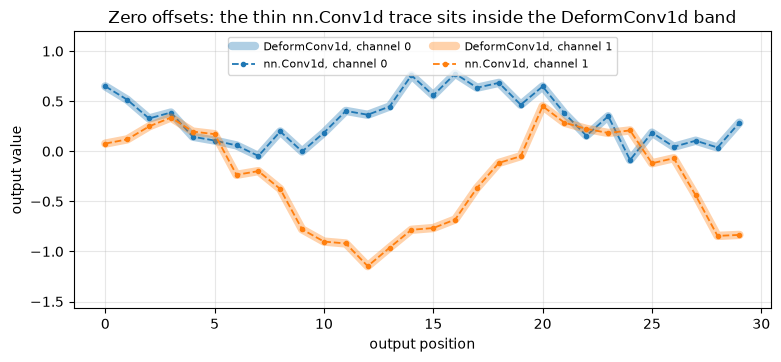

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
t = torch.arange(y_plain.shape[-1])
for c, colour in enumerate(["C0", "C1"]):
    ax.plot(
        t,
        y_deform[0, c].detach(),
        color=colour,
        lw=6,
        alpha=0.35,
        solid_capstyle="round",
        label=f"DeformConv1d, channel {c}",
    )
    ax.plot(
        t,
        y_plain[0, c].detach(),
        color=colour,
        lw=1.3,
        ls="--",
        marker="o",
        markersize=3,
        label=f"nn.Conv1d, channel {c}",
    )
ax.set_xlabel("output position")
ax.set_ylabel("output value")
ax.set_title("Zero offsets: the thin nn.Conv1d trace sits inside the DeformConv1d band")
ax.grid(alpha=0.3)
ax.margins(y=0.22)
ax.legend(loc="upper center", fontsize=8, ncol=2)
save(fig, "01_zero_offset_equivalence")
plt.show()

## 2. An integer offset of `n` shifts the sampled signal by exactly `n`

An offset lands on an exact integer, so no interpolation happens and the sampler simply
reads a different element. This is the cheapest possible check on the indexing
arithmetic, and it also settles a question the documentation never states outright:
**which way does a positive offset move the sample point?**

The answer is that the offset is added to the read position. `out[i] = x[i + n]`, so a
positive offset reads *later* in the input and the output therefore appears shifted
*earlier* (to the left) on the index axis. Near the ends of the sequence the read
position is clamped into range, which is why the traces below flatten at the edges.

In [4]:
L = 32
grid = torch.arange(L, dtype=torch.float32)
x = torch.sin(2 * math.pi * grid / 21.0) + 0.3 * torch.cos(2 * math.pi * grid / 7.0)

for n in (-3, 0, 2, 5):
    y = sample_at(x, torch.full((L,), float(n)))
    expected = x[(torch.arange(L) + n).clamp(0, L - 1)]
    assert torch.equal(y, expected), f"integer offset {n} did not shift by exactly {n}"
    print(f"offset {n:+d}: out[i] == x[i {n:+d}] exactly (edges clamped)")

offset -3: out[i] == x[i -3] exactly (edges clamped)
offset +0: out[i] == x[i +0] exactly (edges clamped)
offset +2: out[i] == x[i +2] exactly (edges clamped)
offset +5: out[i] == x[i +5] exactly (edges clamped)


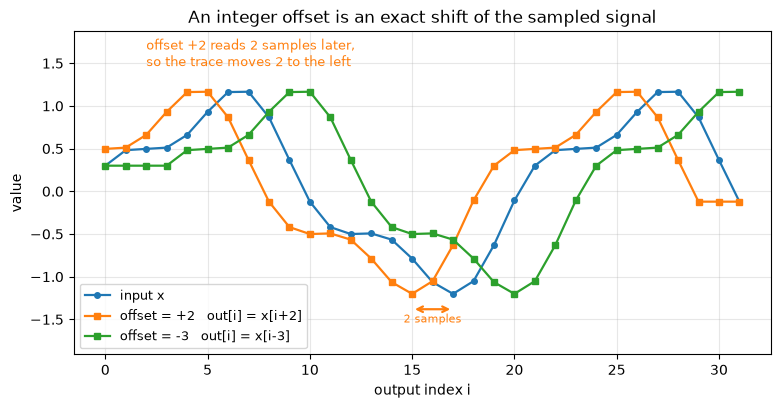

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(grid, x, color="C0", marker="o", markersize=4, lw=1.6, label="input x")
for n, colour in [(2, "C1"), (-3, "C2")]:
    ax.plot(
        grid,
        sample_at(x, torch.full((L,), float(n))),
        color=colour,
        marker="s",
        markersize=4,
        lw=1.6,
        label=f"offset = {n:+d}   out[i] = x[i{n:+d}]",
    )
trough = int(x.argmin())
y_arrow = float(x.min()) - 0.18
ax.annotate(
    "",
    xy=(trough - 2, y_arrow),
    xytext=(trough, y_arrow),
    arrowprops={"arrowstyle": "<->", "color": "C1", "lw": 1.6},
)
ax.text(trough - 1, y_arrow - 0.05, "2 samples", ha="center", va="top", fontsize=8, color="C1")
ax.text(
    2,
    float(x.max()) + 0.25,
    "offset +2 reads 2 samples later,\nso the trace moves 2 to the left",
    fontsize=9,
    color="C1",
    ha="left",
    va="bottom",
)
ax.set_xlabel("output index i")
ax.set_ylabel("value")
ax.set_title("An integer offset is an exact shift of the sampled signal")
ax.grid(alpha=0.3)
ax.margins(y=0.3)
ax.legend(loc="lower left", fontsize=9)
save(fig, "02_integer_offset_shift")
plt.show()

## 3. A fractional offset linearly interpolates between neighbours

This is the core operation of the entire layer, and it is one line of maths: sampling at
position `j + f` for `f` in `[0, 1]` must return `(1 - f) * x[j] + f * x[j + 1]`. Sweep
`f` across a single sample position and plot what comes back. It has to be the straight
line joining `x[j]` to `x[j+1]`, hitting each endpoint exactly.

Exactness at the endpoints is not a detail. `f = 1` returning `x[j+1]` *exactly* is what
makes section 1 hold bit for bit, and it is why the kernel uses `torch.lerp` rather than
the algebraically equal `x0 + f * (x1 - x0)`.

In [6]:
# The interior position with the largest step to its neighbour, so the plot is legible.
j = 4 + int((x[5:29] - x[4:28]).abs().argmax())
fracs = torch.linspace(0, 1, 41)

sampled = []
for f in fracs:
    off = torch.zeros(L)
    off[j] = f
    sampled.append(sample_at(x, off)[j])
sampled = torch.stack(sampled)
analytic = torch.lerp(x[j], x[j + 1], fracs)

assert torch.equal(sampled, analytic), "fractional sampling is not a lerp of the neighbours"
assert sampled[0] == x[j] and sampled[-1] == x[j + 1], "endpoints are not exact"
print(f"x[{j}] = {x[j]:.6f},  x[{j + 1}] = {x[j + 1]:.6f}")
print("max |sampled - (1-f)*x[j] - f*x[j+1]| =", (sampled - analytic).abs().max().item())
print("endpoints exact:", bool(sampled[0] == x[j]), bool(sampled[-1] == x[j + 1]))

x[19] = -0.630076,  x[20] = -0.107708
max |sampled - (1-f)*x[j] - f*x[j+1]| = 0.0
endpoints exact: True True


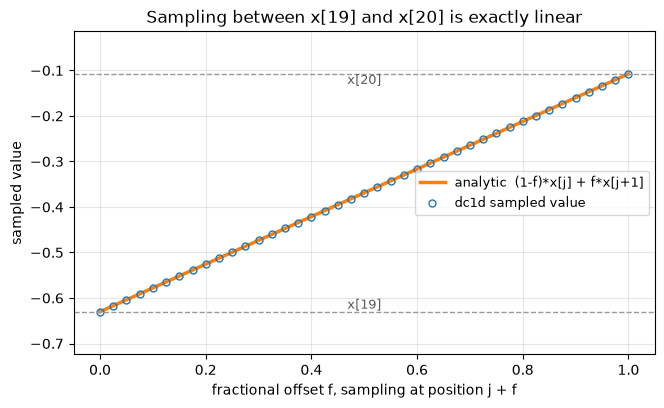

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(fracs, analytic, color="C1", lw=2.5, label="analytic  (1-f)*x[j] + f*x[j+1]")
ax.plot(
    fracs,
    sampled,
    linestyle="none",
    marker="o",
    markersize=5,
    markerfacecolor="none",
    color="C0",
    label="dc1d sampled value",
)
ax.axhline(x[j].item(), color="0.6", ls="--", lw=1)
ax.axhline(x[j + 1].item(), color="0.6", ls="--", lw=1)
ax.text(0.5, x[j].item(), f"x[{j}]", va="bottom", ha="center", fontsize=9, color="0.35")
ax.text(0.5, x[j + 1].item(), f"x[{j + 1}]", va="top", ha="center", fontsize=9, color="0.35")
ax.margins(y=0.18)
ax.set_xlabel("fractional offset f, sampling at position j + f")
ax.set_ylabel("sampled value")
ax.set_title(f"Sampling between x[{j}] and x[{j + 1}] is exactly linear")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
save(fig, "03_fractional_interpolation")
plt.show()

## 4. The offset gradient is correct

The gradient with respect to the offsets is the entire point of a deformable layer: it
is the signal that tells a tap to move. Section 3 showed the forward is piecewise
linear in the offset, so the derivative must be piecewise *constant*, equal to
`x[j+1] - x[j]` on the interval `[j, j+1)`. Below, autograd's value is compared against
a central finite difference across a sweep of offsets spanning five sample intervals.

On the interior of every interval the two agree down to the rounding floor of the
finite difference itself, around 1e-12 in float64. They differ only at the five integer
knots, and that difference is not an error: the forward has a kink there, so the
derivative does not exist. A central difference straddles the kink and returns the mean
of the two one-sided slopes, while autograd returns the right-derivative
`x[j+1] - x[j]`, which is checked exactly below. Picking the right-derivative rather
than an averaged subgradient is what makes section 4b hold. The residual panel makes
the structure visible: flat everywhere, five isolated spikes.

In [8]:
x64 = x.double()
sweep = torch.arange(-250, 251, dtype=torch.float64) / 100.0  # -2.50 to 2.50, step 0.01
h = 1e-4

autograd_grad, fd_grad = [], []
for s in sweep.tolist():
    off = torch.zeros(L, dtype=torch.float64)
    off[j] = s
    off.requires_grad_(True)
    (g,) = torch.autograd.grad(sample_at(x64, off)[j], off)
    autograd_grad.append(g[j])
    with torch.no_grad():
        plus, minus = torch.zeros(L, dtype=torch.float64), torch.zeros(L, dtype=torch.float64)
        plus[j], minus[j] = s + h, s - h
        fd_grad.append((sample_at(x64, plus)[j] - sample_at(x64, minus)[j]) / (2 * h))

autograd_grad = torch.stack(autograd_grad)
fd_grad = torch.stack(fd_grad)
on_knot = (sweep - sweep.round()).abs() < 1e-9

right_deriv = torch.stack([x64[j + k + 1] - x64[j + k] for k in range(-2, 3)])
off_knot_err = (autograd_grad - fd_grad)[~on_knot].abs().max()
knot_err = (autograd_grad - fd_grad)[on_knot].abs().max()

# 1e-11 is the rounding floor of a central difference with h = 1e-4 in float64,
# not a tolerance on the maths: the function is exactly linear between the knots.
assert off_knot_err < 1e-11, "gradient disagrees with the finite difference"
assert torch.equal(autograd_grad[on_knot], right_deriv), "autograd is not the right-derivative"
print("max |autograd - central difference| off the knots:", off_knot_err.item())
print("max |autograd - central difference| at the 5 knots:", knot_err.item(), "(the kink)")
print("autograd at the knots  :", [round(v, 6) for v in autograd_grad[on_knot].tolist()])
print("x[j+k+1] - x[j+k]      :", [round(v, 6) for v in right_deriv.tolist()])

max |autograd - central difference| off the knots: 7.709388682997087e-13
max |autograd - central difference| at the 5 knots: 0.14312314987240882 (the kink)
autograd at the knots  : [0.149042, 0.422046, 0.522368, 0.407708, 0.181802]
x[j+k+1] - x[j+k]      : [0.149042, 0.422046, 0.522368, 0.407708, 0.181802]


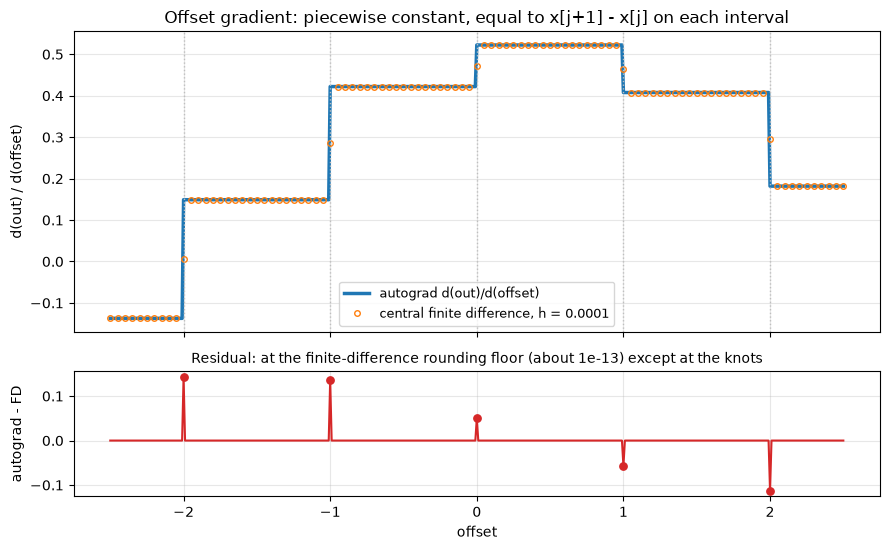

In [9]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 5.6), sharex=True, height_ratios=[2.4, 1])
ax0.plot(sweep, autograd_grad, color="C0", lw=2.5, label="autograd d(out)/d(offset)")
ax0.plot(
    sweep[::5],
    fd_grad[::5],
    linestyle="none",
    marker="o",
    markersize=4,
    markerfacecolor="none",
    color="C1",
    label=f"central finite difference, h = {h:g}",
)
for k in range(-2, 3):
    ax0.axvline(k, color="0.75", ls=":", lw=1)
ax0.set_ylabel("d(out) / d(offset)")
ax0.set_title("Offset gradient: piecewise constant, equal to x[j+1] - x[j] on each interval")
ax0.grid(alpha=0.3)
ax0.legend(loc="best", fontsize=9)

ax1.plot(sweep, autograd_grad - fd_grad, color="C3", lw=1.5)
ax1.scatter(sweep[on_knot], (autograd_grad - fd_grad)[on_knot], color="C3", s=28, zorder=3)
ax1.set_xlabel("offset")
ax1.set_ylabel("autograd - FD")
ax1.set_title(
    "Residual: at the finite-difference rounding floor (about 1e-13) except at the knots",
    fontsize=10,
)
ax1.grid(alpha=0.3)
fig.tight_layout()
save(fig, "04a_offset_gradient_vs_finite_difference")
plt.show()

### 4b. The historical bug, and the invariance that catches it

The interpolation weights `(1 - f)` and `f` sum to 1, so adding a constant to the input
adds that same constant to every sampled value and cannot change the derivative with
respect to the offset. That gives a one-line test with no reference implementation in
it: **compute the offset gradient, add 1000 to the input, compute it again, and require
that nothing moves.**

dc1d 0.0.7 failed this test badly. Its kernel formed the interpolation weights as
`max(0, 1 - |U - T|)`, which at an integer sampling position lands on two
non-differentiable points at once: `|U - T| = 0` for the lower sample, where `abs` has
derivative 0, so the `x[j]` term contributes nothing; and `1 - |U - T| = 0` for the
upper sample, where `max` ties with the zero tensor and splits the gradient in half, so
the `x[j+1]` term contributes `0.5 * x[j+1]`. A tap that also sits on the constrained
clamp is halved once more, to `0.25 * x[j+1]`. The result depends on the *value* of
`x[j+1]` rather than on a difference of neighbouring samples, so it cannot be a
subgradient of an interpolation at all.

The cell below reconstructs that 0.0.7 position arithmetic inline (roughly 15 lines, it
is not installed) and runs both through the same test. `EQUIVALENCE.md` on the
`verify/dtcn-equivalence` branch reports the same comparison against the real PyPI
0.0.7 wheel, measured on CUDA in float64: 0.0.7 returned
`[0.105268, -0.505334, 0.035734]` where 0.1.0 returned the analytic
`[1.574364, -1.431742, 1.153603]`, and adding 1000 to the input moved 0.0.7's gradient
by 5.00e+02 against 0.1.0's 1.05e-13. That is not a rounding difference; it is the
gradient of a different function.

In [10]:
def legacy_007_linterpolate(x, offsets, kernel_size, dilation, stride, unconstrained=False):
    """Reconstruction of the dc1d 0.0.7 `efficient_linterpolate` position arithmetic.

    This is NOT dc1d 0.1.0. It is the pre-rewrite formulation, transcribed from
    repository commit 6ca2e01 (the code published as the 0.0.7 wheel), and it is here
    only so that the two gradients can be compared without installing anything.
    """
    rfield = dilation * (kernel_size - 1) + 1
    dilated = torch.linspace(0, rfield - 1, kernel_size, dtype=offsets.dtype)
    t0s = torch.linspace(
        0, (offsets.shape[-2] - 1) * stride, offsets.shape[-2], dtype=offsets.dtype
    )
    t0s = t0s.unsqueeze(-1)
    T = t0s + dilated + offsets
    if not unconstrained:
        T = torch.min(torch.max(T, t0s), t0s + dilated.max())
    with torch.no_grad():
        U = torch.floor(T).long().clamp(0, x.shape[2] - 2)
        U = torch.stack([U, U + 1], dim=-1)
        if U.shape[1] < x.shape[1]:
            U = U.repeat(1, x.shape[1], 1, 1, 1)
    xr = x.unsqueeze(-1).repeat(1, 1, 1, U.shape[-1])
    xr = torch.stack([xr.gather(index=U[:, :, :, i, :], dim=-2) for i in range(U.shape[-2])], -1)
    weights = torch.max(torch.zeros(U.shape, dtype=T.dtype), 1 - torch.abs(U - T.unsqueeze(-1)))
    return torch.sum(weights * xr.moveaxis(-2, -1), dim=-1)


KS, LG = 3, 16
xg = torch.randn(1, 1, LG, dtype=torch.float64)


def offset_grad(signal, kernel):
    off = torch.zeros(1, 1, LG - KS + 1, KS, dtype=torch.float64, requires_grad=True)
    kernel(signal, off, kernel_size=KS, dilation=1, stride=1, unconstrained=False).sum().backward()
    return off.grad.clone()


analytic_grad = xg[0, 0, 1 : KS + 1] - xg[0, 0, :KS]  # x[j+1] - x[j] for taps 0, 1, 2
rows = []
for name, kernel in [
    ("dc1d 0.1.0", efficient_linterpolate),
    ("0.0.7 reconstruction", legacy_007_linterpolate),
]:
    g0 = offset_grad(xg, kernel)
    g1 = offset_grad(xg + 1000.0, kernel)
    rows.append((name, g0[0, 0, 0], (g1 - g0).abs().max()))

print("analytic d(out)/d(offset) at output position 0, taps 0..2 = x[j+1] - x[j]:")
print("   ", analytic_grad.tolist())
print()
for name, g, delta in rows:
    print(f"{name:22s} gradient {[round(v, 6) for v in g.tolist()]}")
    print(f"{'':22s} max change when x -> x + 1000: {delta:.3e}")
print()
print("0.5  * x[j+1] =", [round(v, 6) for v in (0.5 * xg[0, 0, 1 : KS + 1]).tolist()])
print("0.25 * x[j+1] =", [round(v, 6) for v in (0.25 * xg[0, 0, 1 : KS + 1]).tolist()])

# 0.1.0 is exactly the analytic value and is invariant to the constant shift.
assert torch.allclose(rows[0][1], analytic_grad)
assert rows[0][2] < 1e-12
# The 0.0.7 formulation is neither. Taps 0 and 2 sit on the constrained clamp, so they
# come out as 0.25 * x[j+1]; the interior tap is 0.5 * x[j+1].
assert rows[1][2] > 1.0, "the reconstruction did not reproduce the historical failure"

analytic d(out)/d(offset) at output position 0, taps 0..2 = x[j+1] - x[j]:
    [0.3226309677367232, -0.14660631258569123, -1.6032603988837186]

dc1d 0.1.0             gradient [0.322631, -0.146606, -1.60326]
                       max change when x -> x + 1000: 7.316e-14
0.0.7 reconstruction   gradient [0.211563, 0.349823, -0.225903]
                       max change when x -> x + 1000: 5.000e+02

0.5  * x[j+1] = [0.423127, 0.349823, -0.451807]
0.25 * x[j+1] = [0.211563, 0.174912, -0.225903]


## 5. Sampling positions stay exact in low precision

A sampling position is `window_start + dilated_tap + offset`. The first two terms are
exact integers and only the sub-sample fraction needs to carry the offset dtype, so
dc1d 0.1.0 keeps the integer part in `long` and lets only the fraction be float16.

The pre-rewrite kernel built the whole position with a `linspace` that inherited
`offsets.dtype`. Under autocast that dtype is float16, which cannot represent
consecutive integers past 2048: the spacing there is 2, and 4 past 4096. So the
sampling grid staircases, and a fractional offset smaller than the local spacing
vanishes entirely. There is no NaN and no exception; the numbers are simply wrong.

Below, a float32 ramp `x[i] = i` is sampled with a constant float16 offset of 0.25, so
the value that comes back *is* the sampling position. The naive curve is a
reconstruction of the old approach built with a two-line `linspace`, not dc1d 0.1.0
output; it is labelled as such on the plot.

Past index 2048 the naive error exceeds a whole sample. Part of that is the
representation, and part is the `linspace` accumulating its own error in float16 on top
of it, which is exactly what the pre-rewrite kernel did. At `L = 65536` it would be
worse still, since float16 tops out at 65504.

In [11]:
L_BIG = 4096
OFF = 0.25

ramp = torch.arange(L_BIG, dtype=torch.float32).reshape(1, 1, -1)  # exact in fp32 up to 2**24
fp16_offsets = torch.full((1, 1, L_BIG, 1), OFF, dtype=torch.float16)

dc1d_pos = efficient_linterpolate(ramp, fp16_offsets, 1, 1, 1, unconstrained=True).reshape(-1)

ideal = (torch.arange(L_BIG, dtype=torch.float64) + OFF).clamp(max=L_BIG - 1)
naive_pos = (
    torch.linspace(0, L_BIG - 1, L_BIG, dtype=torch.float16)
    + torch.tensor(OFF, dtype=torch.float16)
).double()

assert torch.equal(dc1d_pos.double(), ideal), "dc1d sampling positions are not exact"
print(f"L = {L_BIG}, constant float16 offset = {OFF}")
print("dc1d 0.1.0   max |position error| =", (dc1d_pos.double() - ideal).abs().max().item())
print("naive (fp16) max |position error| =", (naive_pos - ideal).abs().max().item())
i = 3000
print(f"at index {i}: ideal {ideal[i]:.2f}, dc1d {dc1d_pos[i]:.2f}, naive {naive_pos[i]:.2f}")
print("  -> the naive path lost the 0.25 offset entirely; fp16 has no value between 3000 and 3002")

L = 4096, constant float16 offset = 0.25
dc1d 0.1.0   max |position error| = 0.0
naive (fp16) max |position error| = 1.75
at index 3000: ideal 3000.25, dc1d 3000.25, naive 3000.00
  -> the naive path lost the 0.25 offset entirely; fp16 has no value between 3000 and 3002


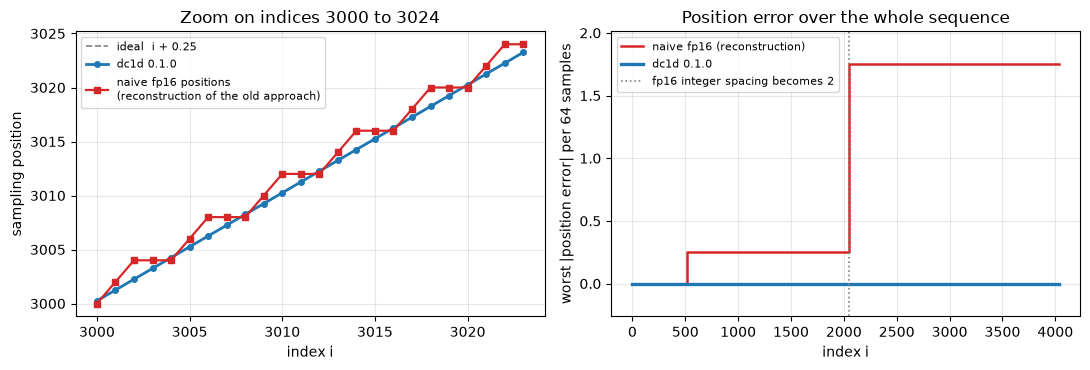

In [12]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.8))

lo, hi = 3000, 3024
zoom = torch.arange(lo, hi)
ax0.plot(zoom, ideal[lo:hi], color="0.5", lw=1.2, ls="--", label="ideal  i + 0.25")
ax0.plot(
    zoom, dc1d_pos[lo:hi].double(), color="C0", lw=2, marker="o", markersize=4, label="dc1d 0.1.0"
)
ax0.plot(
    zoom,
    naive_pos[lo:hi],
    color="C3",
    lw=1.6,
    marker="s",
    markersize=4,
    label="naive fp16 positions\n(reconstruction of the old approach)",
)
ax0.set_xlabel("index i")
ax0.set_ylabel("sampling position")
ax0.set_title(f"Zoom on indices {lo} to {hi}")
ax0.grid(alpha=0.3)
ax0.legend(loc="upper left", fontsize=8)

# The naive error alternates every sample, so plot the worst error per block instead
# of every sample: the raw trace fills solid at this width and shows nothing.
BLOCK = 64
block_x = torch.arange(0, L_BIG, BLOCK)
naive_worst = (naive_pos - ideal).abs().reshape(-1, BLOCK).max(dim=1).values
dc1d_worst = (dc1d_pos.double() - ideal).abs().reshape(-1, BLOCK).max(dim=1).values
ax1.step(
    block_x, naive_worst, where="post", color="C3", lw=1.8, label="naive fp16 (reconstruction)"
)
ax1.step(block_x, dc1d_worst, where="post", color="C0", lw=2.4, label="dc1d 0.1.0")
ax1.axvline(2048, color="0.5", ls=":", lw=1.2, label="fp16 integer spacing becomes 2")
ax1.set_xlabel("index i")
ax1.set_ylabel(f"worst |position error| per {BLOCK} samples")
ax1.set_title("Position error over the whole sequence")
ax1.grid(alpha=0.3)
ax1.margins(y=0.15)
ax1.legend(loc="upper left", fontsize=8)

fig.tight_layout()
save(fig, "05_fp16_sampling_positions")
plt.show()

## 6. It actually learns

The static checks above each pin down one piece. This one exercises all of them at
once: forward, offset gradient and optimiser step, in a loop.

The task is deliberately tiny and has a known answer. A `DeformConv1d` with one input
channel, one output channel, `kernel_size=1` and its weight pinned to 1 and bias to 0 is
exactly the sampler from section 2, so its output is the input read at a learnable
offset. The target is the same signal evaluated at a shift of **3.7 samples**, which is
not an integer, so nothing but genuine sub-sample interpolation can reach it. The
offset starts at 0 and is the only trainable parameter. If the offset gradient is
right, Adam should walk it to 3.7.

The loss settles on a floor of about 1e-6 rather than going to zero, and that floor is
not a failure to converge. The target is a smooth sine evaluated between samples, while
the layer can only produce a straight line between neighbours, so the residual is the
linear-interpolation error of the signal itself.

In [13]:
L_TRAIN, TRUE_SHIFT, STEPS = 256, 3.7, 300


def wave(t):
    return torch.sin(2 * math.pi * t / 64.0) + 0.4 * torch.sin(2 * math.pi * t / 37.0 + 1.0)


grid_t = torch.arange(L_TRAIN, dtype=torch.float32)
signal = wave(grid_t).reshape(1, 1, -1)
target = wave(grid_t + TRUE_SHIFT).reshape(1, 1, -1)

sampler = DeformConv1d(1, 1, kernel_size=1, padding="valid", bias=True, unconstrained=True)
with torch.no_grad():
    sampler.weight.fill_(1.0)
    sampler.bias.zero_()
sampler.weight.requires_grad_(False)
sampler.bias.requires_grad_(False)

shift = nn.Parameter(torch.zeros(1))
opt = torch.optim.Adam([shift], lr=0.2)

MARGIN = 8  # ignore the clamped edges
loss_hist, shift_hist = [], []
for _ in range(STEPS):
    opt.zero_grad()
    offsets = shift.reshape(1, 1, 1, 1).expand(1, 1, L_TRAIN, 1)
    pred = sampler(signal, offsets)
    loss = nn.functional.mse_loss(pred[..., MARGIN:-MARGIN], target[..., MARGIN:-MARGIN])
    loss.backward()
    opt.step()
    loss_hist.append(loss.item())
    shift_hist.append(shift.item())

print(f"true shift    {TRUE_SHIFT}")
print(f"learned shift {shift.item():.4f}   (error {abs(shift.item() - TRUE_SHIFT):.2e})")
print(f"loss          {loss_hist[0]:.4e} -> {loss_hist[-1]:.4e}")
assert abs(shift.item() - TRUE_SHIFT) < 0.02, "the offset did not converge to the true shift"

true shift    3.7
learned shift 3.6994   (error 6.26e-04)
loss          8.7169e-02 -> 1.2014e-06


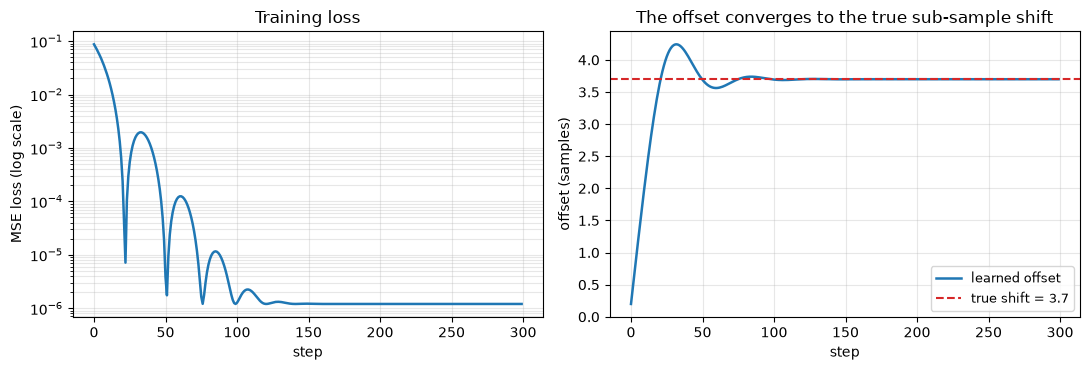

In [14]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.8))

ax0.semilogy(loss_hist, color="C0", lw=1.8)
ax0.set_xlabel("step")
ax0.set_ylabel("MSE loss (log scale)")
ax0.set_title("Training loss")
ax0.grid(alpha=0.3, which="both")

ax1.plot(shift_hist, color="C0", lw=1.8, label="learned offset")
ax1.axhline(TRUE_SHIFT, color="C3", ls="--", lw=1.5, label=f"true shift = {TRUE_SHIFT}")
ax1.set_xlabel("step")
ax1.set_ylabel("offset (samples)")
ax1.set_title("The offset converges to the true sub-sample shift")
ax1.grid(alpha=0.3)
ax1.legend(loc="lower right", fontsize=9)

fig.tight_layout()
save(fig, "06_learned_offset")
plt.show()

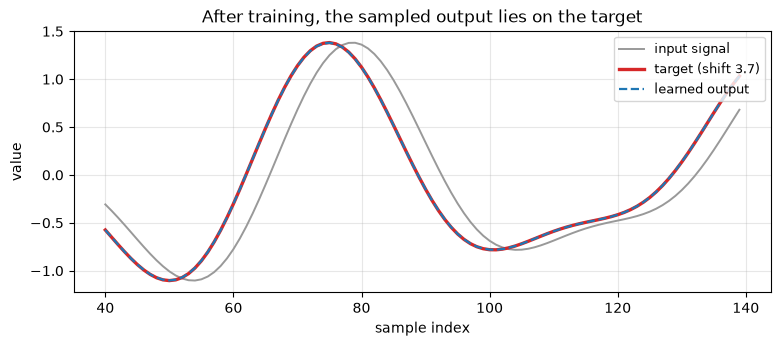

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.4))
window = slice(40, 140)
with torch.no_grad():
    final = sampler(signal, shift.reshape(1, 1, 1, 1).expand(1, 1, L_TRAIN, 1))
ax.plot(grid_t[window], signal[0, 0][window], color="0.6", lw=1.4, label="input signal")
ax.plot(
    grid_t[window], target[0, 0][window], color="C3", lw=2.4, label=f"target (shift {TRUE_SHIFT})"
)
ax.plot(grid_t[window], final[0, 0][window], color="C0", lw=1.6, ls="--", label="learned output")
ax.set_xlabel("sample index")
ax.set_ylabel("value")
ax.set_title("After training, the sampled output lies on the target")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
save(fig, "06b_learned_output_overlay")
plt.show()

## 7. Boundary behaviour

`unconstrained=True` lets a tap sample anywhere in the sequence, so positions can run
off either end. The kernel clamps them, and the clamp is expressed on the split
representation rather than on a materialised position, so the pair weights stay
`(1, 0)` below the range and `(0, 1)` above it. In particular the very last sample is
reachable exactly: sampling at position `L - 1` returns `x[L - 1]` with no interpolation
against a neighbour that does not exist.

x[-1] = 0.5729256868362427
sampled at position L-1 : 0.5729256868362427 (exact, no interpolation)
sampled at position L+1 : 0.5729256868362427 (clamped, no wraparound)


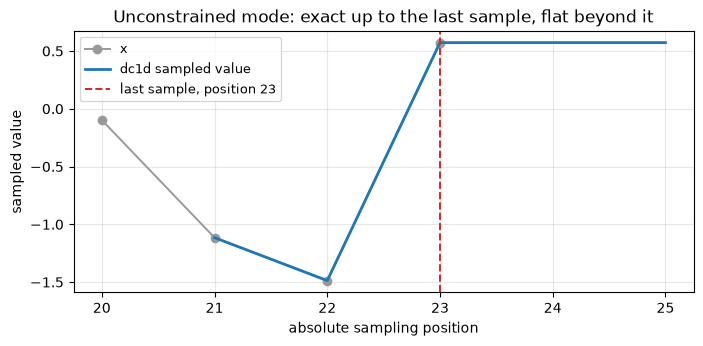

In [16]:
edge = torch.randn(24)
n = edge.shape[0]
positions = torch.linspace(n - 3.0, n + 1.0, 41)  # runs off the right-hand end

# offsets[i] = p - i makes every output index sample at the absolute position p.
ramp_i = torch.arange(n, dtype=torch.float32)
vals = torch.stack([sample_at(edge, p - ramp_i)[0] for p in positions])

last = vals[positions == float(n - 1)]
assert torch.equal(last, edge[-1:]), "position L-1 does not return x[L-1] exactly"
assert torch.all(vals[positions >= n - 1] == edge[-1]), "positions past the end do not clamp"
print("x[-1] =", edge[-1].item())
print("sampled at position L-1 :", last.item(), "(exact, no interpolation)")
print("sampled at position L+1 :", vals[-1].item(), "(clamped, no wraparound)")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(torch.arange(n - 4, n), edge[n - 4 :], color="0.6", marker="o", lw=1.4, label="x")
ax.plot(positions, vals, color="C0", lw=2, label="dc1d sampled value")
ax.axvline(n - 1, color="C3", ls="--", lw=1.4, label=f"last sample, position {n - 1}")
ax.set_xlabel("absolute sampling position")
ax.set_ylabel("sampled value")
ax.set_title("Unconstrained mode: exact up to the last sample, flat beyond it")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
save(fig, "07_boundary_clamp")
plt.show()

## Summary

| # | Property | How it is checked | Result |
|---|---|---|---|
| 1 | Zero offsets equal `nn.Conv1d` | `torch.equal` | exact |
| 2 | Integer offset `n` shifts by `n` | `torch.equal` against `x[i+n]` | exact |
| 3 | Fractional offset interpolates | `torch.equal` against the analytic lerp | exact |
| 4 | Offset gradient | central finite difference; constant-shift invariance | exact off the knots |
| 5 | fp16 sampling positions | compared to the exact integer grid | exact |
| 6 | Offsets train | Adam recovers a 3.7-sample shift | error < 1e-3 |
| 7 | Boundary clamp | last sample reachable exactly | exact |

Every one of these is asserted above, so re-executing this notebook is itself a test.
For the full suite see `tests/`, in particular `tests/test_equivalence.py` (property 1
across stride, dilation and groups) and `tests/test_gradients.py` (`gradcheck` in
float64 against both the input and the offsets).